<a href="https://colab.research.google.com/github/FishyFoshy/COMP3608-Project/blob/main/Dataset_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Cleaning of Dataset 3

In [38]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
import numpy as np
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Load datasets
df3 = pd.read_csv('Dataset 3.csv')

# Drops all unnecessary columns
df3 = df3.drop(columns=['id', 'date', 'yr_renovated', 'zipcode', 'sqft_living15', 'sqft_lot15'])

# Drops all with null values
df3.dropna(inplace=True)

# Separates non numerical columns from numerical ones
non_numerical_columns = ['price']
numerical_features = [col for col in df3.columns if col not in non_numerical_columns]

df3_outr = df3.copy()

#Log Transform
df3['price'] = np.log1p(df3['price'])


# Scale numerical features
scaler = StandardScaler()
df3[numerical_features] = scaler.fit_transform(df3[numerical_features])

# One-Hot Encodes all categorical data
categorical_cols_to_encode = df3.select_dtypes(include='object').columns
df3 = pd.get_dummies(df3, columns=categorical_cols_to_encode, drop_first=True)



# Identifies target column from the features
target_column = 'price'
features = [col for col in df3.columns if col != target_column]

x = df3[features].copy()
y = df3[target_column].copy()

# Splits the data 80/20 for training and testing the model respectfully
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("=" * 60)
print("DATASET 3: Dataset 1.csv")
print("=" * 60)
print("\nFirst 10 rows:")
display(df3.head(10))
print("\nData types:")
print(df3.dtypes)
print("\nMissing values:")
print(df3.isnull().sum())
print("\nTarget variable (price) statistics:")
print(df3['price'].describe())

DATASET 3: Dataset 1.csv

First 10 rows:


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,lat,long
0,12.309987,-0.398737,-1.447464,-0.979835,-0.228321,-0.915427,-0.087173,-0.305759,-0.629187,-0.558836,-0.734708,-0.658681,-0.544898,-0.352572,-0.306079
1,13.195616,-0.398737,0.175607,0.533634,-0.189885,0.936506,-0.087173,-0.305759,-0.629187,-0.558836,0.460841,0.245141,-0.681079,1.161568,-0.746341
2,12.100718,-1.473959,-1.447464,-1.426254,-0.123298,-0.915427,-0.087173,-0.305759,-0.629187,-1.409587,-1.229834,-0.658681,-1.293892,1.283537,-0.135655
3,13.311331,0.676485,1.149449,-0.130550,-0.244014,-0.915427,-0.087173,-0.305759,2.444294,-0.558836,-0.891699,1.397515,-0.204446,-0.283288,-1.271816
4,13.142168,-0.398737,-0.149007,-0.435422,-0.169653,-0.915427,-0.087173,-0.305759,-0.629187,0.291916,-0.130895,-0.658681,0.544548,0.409550,1.199335
5,14.018452,0.676485,3.097133,3.636791,2.096185,-0.915427,-0.087173,-0.305759,-0.629187,2.844170,2.537955,2.798440,1.021181,0.693181,1.483375
6,12.458779,-0.398737,0.175607,-0.397313,-0.200098,0.936506,-0.087173,-0.305759,-0.629187,-0.558836,-0.088628,-0.658681,0.816910,-1.806810,-0.803149
7,12.583999,-0.398737,-0.798235,-1.110494,-0.130276,-0.915427,-0.087173,-0.305759,-0.629187,-0.558836,-0.879623,-0.658681,-0.272536,-1.086547,-0.717937
8,12.343663,-0.398737,-1.447464,-0.326539,-0.184381,-0.915427,-0.087173,-0.305759,-0.629187,-0.558836,-0.891699,0.990795,-0.374672,-0.344633,-0.874160
9,12.685411,-0.398737,0.500221,-0.206768,-0.206351,0.936506,-0.087173,-0.305759,-0.629187,-0.558836,0.122706,-0.658681,1.089271,-1.383168,1.298749



Data types:
price            float64
bedrooms         float64
bathrooms        float64
sqft_living      float64
sqft_lot         float64
floors           float64
waterfront       float64
view             float64
condition        float64
grade            float64
sqft_above       float64
sqft_basement    float64
yr_built         float64
lat              float64
long             float64
dtype: object

Missing values:
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
lat              0
long             0
dtype: int64

Target variable (price) statistics:
count    21613.000000
mean        13.047819
std          0.526683
min         11.225257
25%         12.682155
50%         13.017005
75%         13.377007
max         15.856731
Name: price, dtype: float64


# Linear Regression for Dataset 3

In [39]:
from sklearn.model_selection import cross_val_score, KFold,cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,root_mean_squared_error,get_scorer_names, make_scorer
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn import metrics

model = LinearRegression()
model.fit(x_train,y_train)
predictions = model.predict(x_test)







----Log Space Metrics---
RMSE: $0.26
MAE: $0.20
r2: 0.7602

--- Real-Space Metrics ---
RMSE: $330,920.82
MAE: $120,547.17
r2: 0.2756

--- Cross Validated Scores ---
RMSE: $208,690.17
MAE: $112,274.42
r2: 0.7604



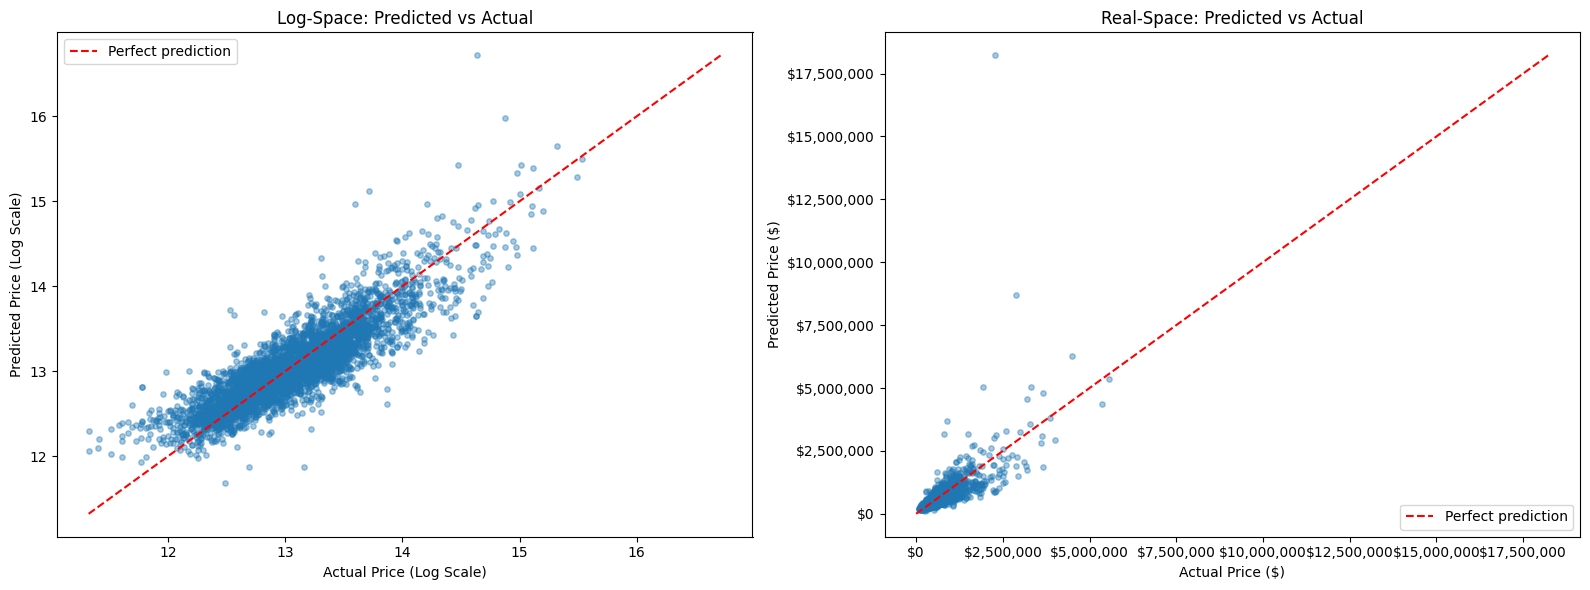

In [40]:
y_test_real = np.expm1(y_test)
predictions_real = np.expm1(predictions)

print("----Log Space Metrics---")
print(f"RMSE: ${metrics.root_mean_squared_error(y_test, predictions):,.2f}")
print(f"MAE: ${metrics.mean_absolute_error(y_test, predictions):,.2f}")
print(f"r2: {metrics.r2_score(y_test, predictions):.4f}\n")




print("--- Real-Space Metrics ---")
print(f"RMSE: ${metrics.root_mean_squared_error(y_test_real, predictions_real):,.2f}")
print(f"MAE: ${metrics.mean_absolute_error(y_test_real, predictions_real):,.2f}")
print(f"r2: {metrics.r2_score(y_test_real, predictions_real):.4f}\n")

#Cross Validation
def real_rmse_func(y_true, y_pred):
    return metrics.root_mean_squared_error(np.expm1(y_true), np.expm1(y_pred))

def real_mae_func(y_true, y_pred):
    return metrics.mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))

scoring_dict = {
    'real_mae': make_scorer(real_mae_func, greater_is_better=False),
    'real_rmse': make_scorer(real_rmse_func, greater_is_better=False),
    'r2': 'r2' 
}

cv_results = cross_validate(model, x_train, y_train, cv=5, scoring=scoring_dict, return_train_score=True)

print("--- Cross Validated Scores ---")
print(f"RMSE: ${-cv_results['test_real_rmse'].mean():,.2f}")
print(f"MAE: ${-cv_results['test_real_mae'].mean():,.2f}")
print(f"r2: {cv_results['test_r2'].mean():.4f}\n")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


ax1.scatter(y_test, predictions, alpha=0.4, s=15)
max_val_log = max(y_test.max(), predictions.max())
min_val_log = min(y_test.min(), predictions.min())
ax1.plot([min_val_log, max_val_log], [min_val_log, max_val_log], 'r--', label='Perfect prediction')
ax1.set_xlabel('Actual Price (Log Scale)') 
ax1.set_ylabel('Predicted Price (Log Scale)')
ax1.set_title('Log-Space: Predicted vs Actual')
ax1.legend()


ax2.scatter(y_test_real, predictions_real, alpha=0.4, s=15)
max_val_real = max(y_test_real.max(), predictions_real.max())
ax2.plot([0, max_val_real], [0, max_val_real], 'r--', label='Perfect prediction')
ax2.set_xlabel('Actual Price ($)') 
ax2.set_ylabel('Predicted Price ($)')
ax2.set_title('Real-Space: Predicted vs Actual')
ax2.legend()

# Format the Real-Space graph to show dollar amounts
formatter = ticker.StrMethodFormatter('${x:,.0f}') 
ax2.xaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

This dataset has a very small amount of large outliers. Even with a log transformation the outlers are just to far from most of the other values to make strong predictions on the higher end mansions. These small amount of extremely expensive houses violate the homoscedasticity expectation(Equal Variacnes) for the linear regression model. So atleast for this dataset you can get the a reasonably accurate model if you are only intrested in figuring out which bucket(a house will fall in based on it's features) which is why we get reasonable R^2 value in log space(.76) but as soon as we reintroduce granularity by converting back out of log space you the model the errors get blown up and the accuracy plummets. Understanding this it makes sense to create two seperate models one in that stays in log space(this time in log10(x)) which is able to find extremly expensive housing and another that is able to differentiate between houses that are less than $500 000 apart.

Constructing the two linear models 

## Linear Model with the Outliers Removed

RMSE: $174,795.15
MAE: $117,843.91
r2: 0.6929

Cross-validation RMSE:	$169,717.12
Cross-validation MAE:	$114,433.28
Cross-validation R²:	0.6993


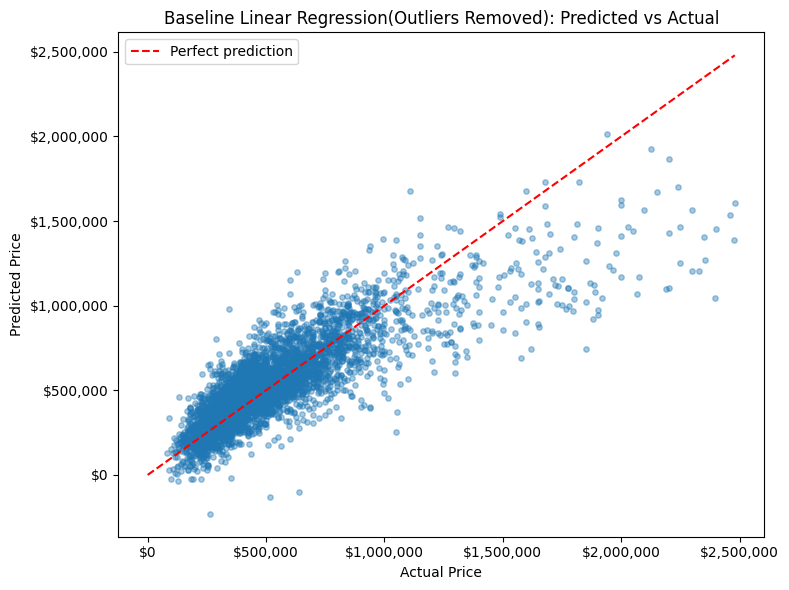

In [41]:
#Filter: Drop the extremely expensive houses
df3_outr = df3_outr[df3_outr['price'] < 2500000]


# Scale numerical features
scaler = StandardScaler()
df3_outr[numerical_features] = scaler.fit_transform(df3_outr[numerical_features])

# One-Hot Encodes all categorical data
categorical_cols_to_encode = df3_outr.select_dtypes(include='object').columns
df3_outr = pd.get_dummies(df3_outr, columns=categorical_cols_to_encode, drop_first=True)

#Extracting Features
target_column = 'price'
features = [col for col in df3_outr.columns if col != target_column]

#Creating "X" and "Y"
x_g = df3_outr[features].copy()
y_g = df3_outr[target_column].copy()

#Creating split
x_train_g, x_test_g, y_train_g, y_test_g = train_test_split(x_g, y_g, test_size=0.2, random_state=42)

#Creating Model
model_1 = LinearRegression()
model_1.fit(x_train_g, y_train_g)
predictions = model_1.predict(x_test_g)

#Printing Metrics
print(f"RMSE: ${metrics.root_mean_squared_error(y_test_g, predictions):,.2f}")
print(f"MAE: ${metrics.mean_absolute_error(y_test_g, predictions):,.2f}")
print(f"r2: {metrics.r2_score(y_test_g, predictions):.4f}")

#Cross Validated Metrics
print(f"\nCross-validation RMSE:\t${-cross_val_score(model_1, x_g, y_g, cv=5, scoring='neg_root_mean_squared_error').mean():,.2f}")
print(f"Cross-validation MAE:\t${-cross_val_score(model_1, x_g, y_g, cv=5, scoring='neg_mean_absolute_error').mean():,.2f}")
print(f"Cross-validation R²:\t{cross_val_score(model_1, x_g, y_g, cv=5, scoring='r2').mean():.4f}")

#Plotting Curve of Prediction vs Actual to show the accuracy 
plt.figure(figsize=(8, 6))
plt.scatter(y_test_g, predictions, alpha=0.4, s=15)
max_val = max(y_test_g.max(), predictions.max()) 
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
plt.xlabel('Actual Price') 
plt.ylabel('Predicted Price')
plt.title('Baseline Linear Regression(Outliers Removed): Predicted vs Actual')
plt.legend()
ax = plt.gca() 
import matplotlib.ticker as ticker # Ensure ticker is imported
formatter = ticker.StrMethodFormatter('${x:,.0f}') 
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)
plt.tight_layout()  
plt.show()

This model is more in line with what you'd expect from a well constructed linear model the measures of varaince and graphs are all within acceptable parameters. You could make the model even more accurate by getting rid of the cluster past 2 million this would yield a model closer to 75% however culling good data is generally bad practice in Machine Learning/Data Science.

### Further Analyisis of the Model with the Outliers Removed

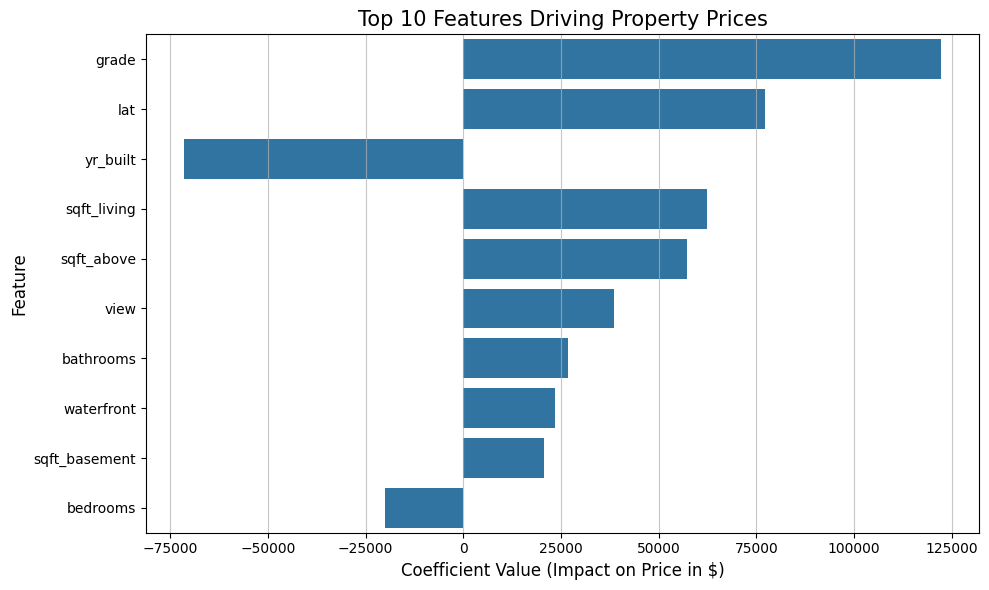

,Feature,Coefficient
8,grade,122272.498194
12,lat,77201.100389
11,yr_built,-71555.606940
2,sqft_living,62378.658094
9,sqft_above,57272.383681
6,view,38439.995440
1,bathrooms,26691.774339
5,waterfront,23393.215460
10,sqft_basement,20508.947760
0,bedrooms,-20015.054715


In [42]:
import seaborn as sns
#Fetching Feature Names and Coefficents
feature_names = x_train_g.columns
coefficients = model_1.coef_

#Wrapping them together in a Pandas DataFrame for Easy Comparision and Viewing
feature_importance = pd.DataFrame({
 'Feature': feature_names,
 'Coefficient': coefficients
})

#Using the Absolute Function in the NumPy Library before Sorting the Coefficents in Decending Order
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
top_10_features = feature_importance.sort_values(by='Abs_Coefficient', ascending=False).head(10)

#Plotting Graph
plt.figure(figsize=(10, 6))
sns.barplot(
 data=top_10_features, 
 x='Coefficient', 
 y='Feature', 
)
#Graph of the Top 10 features
plt.title('Top 10 Features Driving Property Prices', fontsize=15)
plt.xlabel('Coefficient Value (Impact on Price in $)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(True, axis='x', linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()
display(top_10_features[['Feature', 'Coefficient']])


From the graph year built and number of bedrooms are our negative predictors. Older homes seem to be commanding a premium over newer ones. Older homes most likely because older homes are typically sold by indivduals or real estate. Compared to large private investors who are more incentivicized to sell at below market or at market rates to quickly make a return on their investmets. However the more intresting feature has to be bedrooms. Intutively you'd expect houses with more bedrooms to be more valuable. The best guess for why this would be the case is because the data is so tightly clustered around 100k-1million and the cutoff for the dataset was 2.5 million houeses in these price ranges. So most houses have around the same number of bedrooms. This may cause the number of bedrooms to become coupled to an expected negative predictor like year built. Modern houes tend to forgoe the 4th bedroom wether it be the trend toward larger shared spaces(leaving less square footage for a 4th or 5th bedroom) or simply smaller families buying houeses. Add to that the removal of the few mansions from the dataset also get rid of the massive 12+ bedroom houses that may have changed how this feature is weighted in the model signficiantly.

The positive predictors arent as intresting. Large, Modern, Well constructed houeses on larger plots of land with extra ammenities do better than houeses without these things. However it seems the quality construction of a house vastly outweigh the size of the house or even the land it sits on.

## Log Scaled Model Features Evaulation

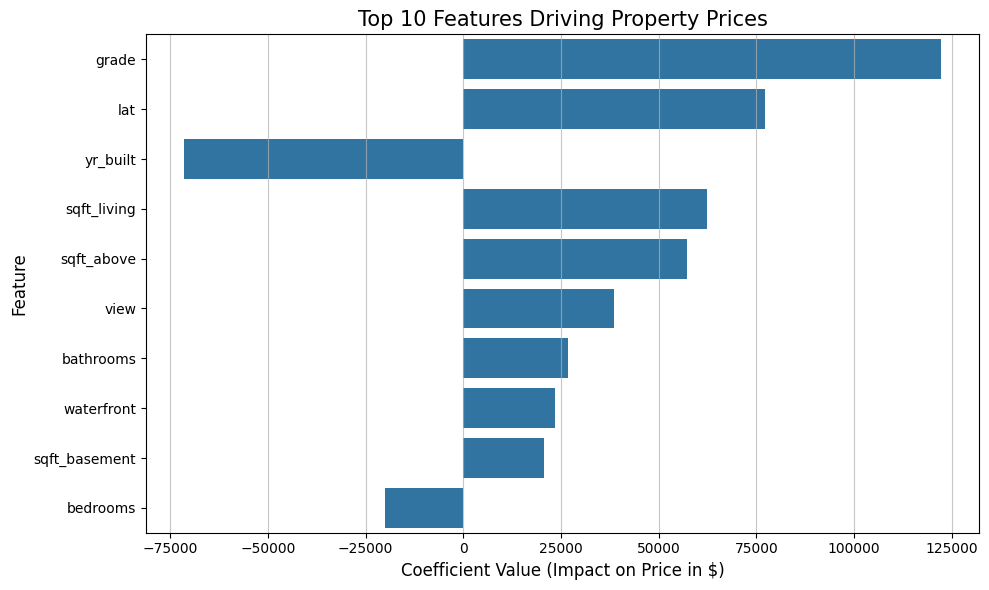

,Feature,Coefficient
8,grade,122272.498194
12,lat,77201.100389
11,yr_built,-71555.606940
2,sqft_living,62378.658094
9,sqft_above,57272.383681
6,view,38439.995440
1,bathrooms,26691.774339
5,waterfront,23393.215460
10,sqft_basement,20508.947760
0,bedrooms,-20015.054715


In [43]:
#Fetching Feature Names and Coefficents
feature_names = x_train.columns
coefficients = model_1.coef_

#Wrapping them together in a Pandas DataFrame for Easy Comparision and Viewing
feature_importance = pd.DataFrame({
 'Feature': feature_names,
 'Coefficient': coefficients
})

#Using the Absolute Function in the NumPy Library before Sorting the Coefficents in Decending Order
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
top_10_features = feature_importance.sort_values(by='Abs_Coefficient', ascending=False).head(10)

#Plotting Graph
plt.figure(figsize=(10, 6))
sns.barplot(
 data=top_10_features, 
 x='Coefficient', 
 y='Feature', 
)
#Graph of the Top 10 features
plt.title('Top 10 Features Driving Property Prices', fontsize=15)
plt.xlabel('Coefficient Value (Impact on Price in $)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(True, axis='x', linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()
display(top_10_features[['Feature', 'Coefficient']])


-Since X was not log scaled the analysis from Previously applies

## Random Forest Regression

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("Training Random Forest... This may take a moment depending on dataset size.")
rf_model.fit(x_train, y_train)

# Generate predictions on the log-scaled test set
rf_predictions = rf_model.predict(x_test)


#Generate Cross Validation Metrics in Log Space
print("\n--- Log-Space Metrics (Random Forest) ---")
print(f"RMSE: {metrics.root_mean_squared_error(y_test, rf_predictions):.4f}")
print(f"MAE:  {metrics.mean_absolute_error(y_test, rf_predictions):.4f}")
print(f"R²:   {metrics.r2_score(y_test, rf_predictions):.4f}\n")

print(f"\nCross-validation RMSE:\t{-cross_val_score(rf_model, x, y, cv=5, scoring='neg_root_mean_squared_error').mean():,.2f}")
print(f"Cross-validation MAE:\t{-cross_val_score(rf_model, x, y, cv=5, scoring='neg_mean_absolute_error').mean():,.2f}")
print(f"Cross-validation R²:\t{cross_val_score(rf_model, x, y, cv=5, scoring='r2').mean():.4f}")

#Real Space Metrics
y_test_real = np.expm1(y_test)
rf_predictions_real = np.expm1(rf_predictions)

print("--- Real-Space (Dollar) $ Metrics (Random Forest) ---")
print(f"RMSE: ${metrics.root_mean_squared_error(y_test_real, rf_predictions_real):,.2f}")
print(f"MAE:  ${metrics.mean_absolute_error(y_test_real, rf_predictions_real):,.2f}")
print(f"R²:   {metrics.r2_score(y_test_real, rf_predictions_real):.4f}\n")



Training Random Forest... This may take a moment depending on dataset size.

--- Log-Space Metrics (Random Forest) ---
RMSE: 0.1780
MAE:  0.1271
R²:   0.8889


Cross-validation RMSE:	$0.18
Cross-validation MAE:	$0.13
Cross-validation R²:	0.8871
--- Real-Space (Dollar) $ Metrics (Random Forest) ---
RMSE: $137,767.04
MAE:  $72,432.18
R²:   0.8745



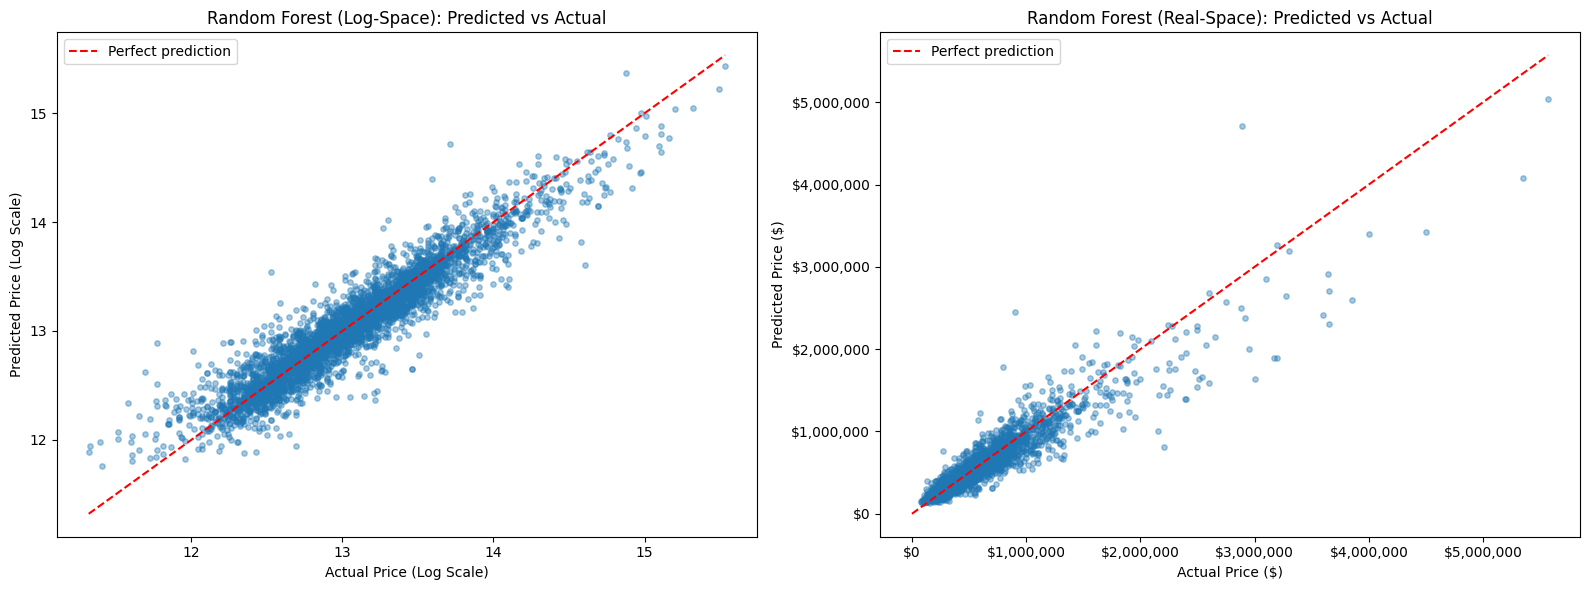

In [ ]:
#Plotting Graphs that compare the real space predictions and the log scaled predictions accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

#Log-Space Graph
ax1.scatter(y_test, rf_predictions, alpha=0.4, s=15,) 
max_val_log = max(y_test.max(), rf_predictions.max())
min_val_log = min(y_test.min(), rf_predictions.min())
ax1.plot([min_val_log, max_val_log], [min_val_log, max_val_log], 'r--', label='Perfect prediction')
ax1.set_xlabel('Actual Price (Log Scale)') 
ax1.set_ylabel('Predicted Price (Log Scale)')
ax1.set_title('Random Forest (Log-Space): Predicted vs Actual')
ax1.legend()

#Real-Space Graph
ax2.scatter(y_test_real, rf_predictions_real, alpha=0.4, s=15,)
max_val_real = max(y_test_real.max(), rf_predictions_real.max())
ax2.plot([0, max_val_real], [0, max_val_real], 'r--', label='Perfect prediction')
ax2.set_xlabel('Actual Price ($)') 
ax2.set_ylabel('Predicted Price ($)')
ax2.set_title('Random Forest (Real-Space): Predicted vs Actual')
ax2.legend()
formatter = ticker.StrMethodFormatter('${x:,.0f}') 
ax2.xaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)
plt.tight_layout()
plt.show()

The Combination of a log scale transformation and a model that assumes unequal variances allow for the generation of a model the completely curshes either of the previous linear models. In every single metric improvements of over 25% can be seen in MAE, RMSE, R^2. For this model there is should be no need to generate a seperate model. That model that provides simillar accuracy across the entire dataset. 

### Analyisis of Feature Importance for The Random Forest Model

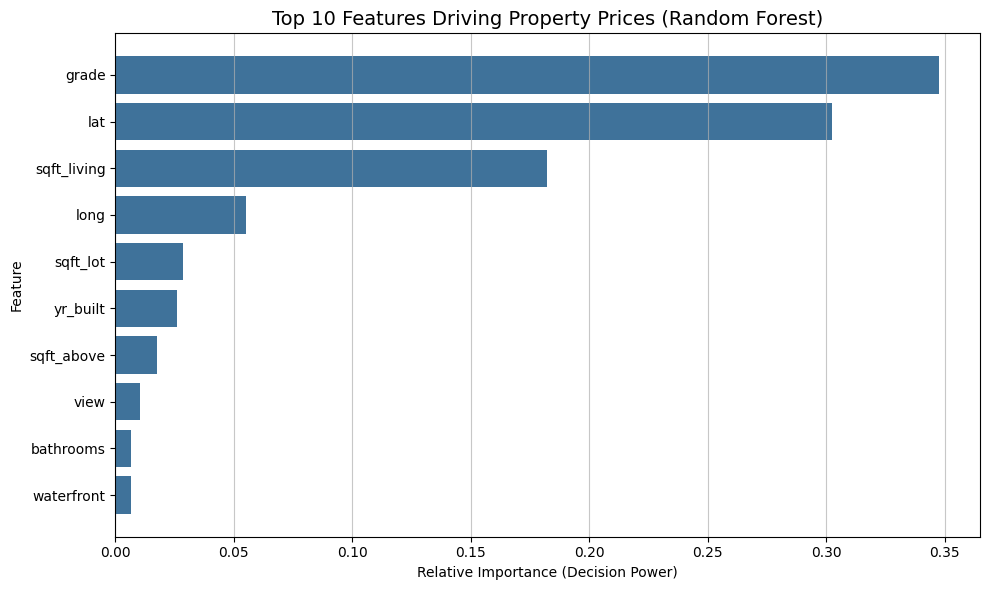

In [ ]:

#Extract the feature importances from the Random Forest model
importances = rf_model.feature_importances_
feature_names = x_train.columns
feature_df = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': importances
})

#Sorting By importance
top_10_features = feature_df.sort_values(by='Importance', ascending=True).tail(10)

#Plotting Graph
plt.figure(figsize=(10, 6))
plt.barh(top_10_features['Feature'], top_10_features['Importance'], color='#3f729a') 
plt.xlabel('Relative Importance (Decision Power)')
plt.ylabel('Feature')
plt.title('Top 10 Features Driving Property Prices (Random Forest)', fontsize=14)
plt.grid(axis='x', linestyle='-', alpha=0.7) 
plt.tight_layout()
plt.show()

The inclusion of the outliers that caused most of the problems in the previous model. Slightly changed the order of the top10 features. Firstly the number of bedrooms is no longer as strong a predictor. Which was expected. Even though there is a trend toward building less new houses with 4+ bedrooms the inclusion of mansions with 12+ bedrooms with evaluations that massively exceed the other houses made the model less willing to rely on this as a strong negative predictor if it is even a negative predictor at all anymore(One of the limitations of the random forest model). Another change in this model is that longitude is now a top5 predictor even though it was not even a top10 predictor for the linear model. Previously the model decided the closer you were to the north the more valuable the house would be. This may be due to a general pattern of class and wealth stratifcation in the north of western countries such as the US and Europe. NYC for exmaple has much higher salaries and housing prices than Oklahoma. In this model however it weighs both more equally(Favoring Latitude more thhan Longitude)